In [20]:
# Data source: Synthetic dataset generated in Python for academic ML assignment (150 rows)

import pandas as pd
import numpy as np

np.random.seed(42)

# Generate 150 rows
n = 150

square_footage = np.random.randint(1500, 3000, n)
locations = np.random.choice(['Downtown', 'Suburb', 'Rural'], n)

# Base price per square foot
price_per_sqft = 200

# Location adjustments
location_adjustment = {
    'Downtown': 150000,
    'Suburb': 50000,
    'Rural': -50000
}

prices = [
    sqft * price_per_sqft + location_adjustment[loc] + np.random.randint(-20000, 20000)
    for sqft, loc in zip(square_footage, locations)
]

df = pd.DataFrame({
    'square_footage': square_footage,
    'location': locations,
    'price': prices
})

df.head()


,square_footage,location,price
0,2626,Rural,458161
1,2959,Rural,543157
2,2360,Rural,413969
3,2794,Downtown,691669
4,2630,Downtown,684643


In [21]:
# Correct way to predict: pass a DataFrame with the same column names used in training
import pandas as pd

sample = pd.DataFrame({
    'square_footage': [2000],
    'location': ['Downtown']
})

pred = model.predict(sample)[0]
print("Predicted price for a 2000 sq ft house in Downtown: ${:,.2f}".format(pred))


Predicted price for a 2000 sq ft house in Downtown: $549,782.01


In [22]:
reg = model.named_steps['regressor']
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

print("\nModel Coefficients:")
for name, coef in zip(feature_names, reg.coef_):
    print(f"{name}: {coef:.2f}")



Model Coefficients:
cat__location_Rural: -201188.80
cat__location_Suburb: -99782.17
remainder__square_footage: 195.94


In [23]:
# Data source: Synthetic customer churn dataset generated in Python for academic ML assignment (200 rows)

import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

age = np.random.randint(18, 70, n)
monthly_usage = np.random.randint(10, 100, n)
purchase_amount = np.random.randint(20, 500, n)
customer_service_calls = np.random.randint(0, 10, n)
region = np.random.choice(['North', 'South', 'East', 'West'], n)

# Create churn probability logic
churn_prob = (
    0.3 * (customer_service_calls / 10) +
    0.3 * (1 - purchase_amount / 500) +
    0.2 * (1 - monthly_usage / 100)
)

churn = (churn_prob + np.random.normal(0, 0.1, n) > 0.5).astype(int)

df_churn = pd.DataFrame({
    'age': age,
    'monthly_usage': monthly_usage,
    'purchase_amount': purchase_amount,
    'customer_service_calls': customer_service_calls,
    'region': region,
    'churn': churn
})

df_churn.head()


,age,monthly_usage,purchase_amount,customer_service_calls,region,churn
0,56,79,161,8,South,1
1,69,81,479,7,South,0
2,46,36,390,2,South,0
3,32,18,490,0,South,0
4,60,71,162,2,South,1


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df_churn.drop('churn', axis=1)
y = df_churn['churn']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['age', 'monthly_usage', 'purchase_amount', 'customer_service_calls']),
        ('cat', OneHotEncoder(drop='first'), ['region'])
    ]
)

model_churn = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model_churn.fit(X, y)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'monthly_usage',
                                                   'purchase_amount',
                                                   'customer_service_calls']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['region'])])),
                ('classifier', LogisticRegression())])

In [25]:
import pandas as pd

sample_customer = pd.DataFrame({
    'age': [30],
    'monthly_usage': [40],
    'purchase_amount': [100],
    'customer_service_calls': [6],
    'region': ['West']
})

prob = model_churn.predict_proba(sample_customer)[0][1]

print(f"Churn probability: {prob:.2f}")

if prob >= 0.5:
    print("Customer classified as: At Risk of Churn (1)")
else:
    print("Customer classified as: Not at Risk (0)")


Churn probability: 0.60
Customer classified as: At Risk of Churn (1)


In [26]:
clf = model_churn.named_steps['classifier']
feature_names = model_churn.named_steps['preprocessor'].get_feature_names_out()

print("Logistic Regression Coefficients (positive = higher churn likelihood):\n")
for name, coef in zip(feature_names, clf.coef_[0]):
    print(f"{name}: {coef:.3f}")


Logistic Regression Coefficients (positive = higher churn likelihood):

num__age: -0.284
num__monthly_usage: -0.636
num__purchase_amount: -1.482
num__customer_service_calls: 1.602
cat__region_North: 0.592
cat__region_South: -0.151
cat__region_West: -0.657


In [27]:
# Data source: Synthetic customer segmentation dataset generated in Python (200 rows)

import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

annual_spending = np.random.randint(500, 20000, n)
purchase_frequency = np.random.randint(1, 50, n)
age = np.random.randint(18, 70, n)
region = np.random.choice(['North', 'South', 'East', 'West'], n)

df_seg = pd.DataFrame({
    'annual_spending': annual_spending,
    'purchase_frequency': purchase_frequency,
    'age': age,
    'region': region
})

df_seg.head()


,annual_spending,purchase_frequency,age,region
0,16295,1,64,South
1,1360,11,51,East
2,5890,28,49,West
3,12464,25,65,West
4,11784,23,42,North


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    df_seg[['annual_spending', 'purchase_frequency', 'age']]
)


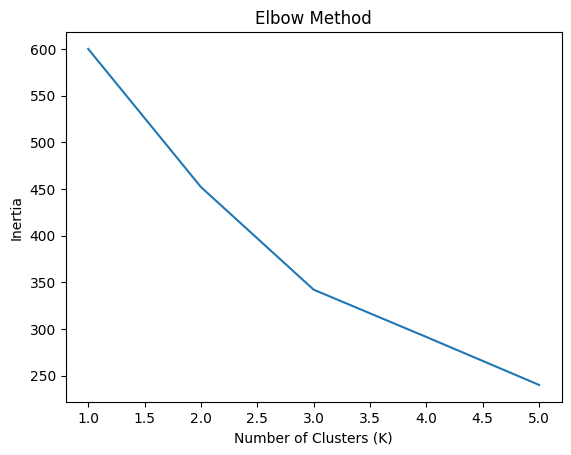

<Figure size 640x480 with 0 Axes>

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, 6), inertia)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

plt.savefig("elbow_plot.png")


In [30]:
kmeans = KMeans(n_clusters=3, random_state=42)
df_seg['cluster'] = kmeans.fit_predict(scaled_features)

df_seg.head()


,annual_spending,purchase_frequency,age,region,cluster
0,16295,1,64,South,1
1,1360,11,51,East,0
2,5890,28,49,West,1
3,12464,25,65,West,1
4,11784,23,42,North,2


In [31]:
cluster_summary = df_seg.groupby('cluster')[['annual_spending', 'purchase_frequency', 'age']].mean()
print(cluster_summary)


         annual_spending  purchase_frequency        age
cluster                                                
0            4707.420000           12.220000  41.780000
1           10655.065789           31.210526  58.315789
2           12878.310811           31.378378  31.891892


In [32]:
df_seg.to_csv("customer_segments.csv", index=False)


Elbow Method Explanation

The elbow plot shows inertia decreasing as the number of clusters increases. The curve begins to level off around K = 3, suggesting that three clusters provide a good balance between simplicity and segmentation quality.

Cluster Analysis

The clusters represent groups of customers with similar spending behavior, purchase frequency, and age characteristics. For example, one cluster may represent high-spending frequent buyers, another may represent low-spending infrequent customers, and another may represent moderate buyers.

Marketing Strategies

High-spending customers can be targeted with loyalty programs and exclusive promotions.
Low-spending customers may benefit from discounts or incentives to increase engagement.
Moderate customers can receive personalized recommendations to increase purchase frequency.

**Part 1: House Price Prediction (Linear Regression)**

Data source comment (synthetic, 150 rows)

Show df.head()

Train model

Predict 2000 sq ft Downtown

Print coefficients

The linear regression model predicts house prices based on square footage and location. The coefficient for square_footage represents the average increase in price for each additional square foot. In this model, the value is approximately $196 per square foot, meaning that larger homes tend to increase in price proportionally.

**Part 2: Customer Churn Prediction (Logistic Regression)**

Data source comment (synthetic, 200 rows)

Show df_churn.head()

Train model (scaler + onehot)

Print churn probability + 0.5 classification

Print coefficients

The logistic regression model predicts the probability that a customer will churn (stop doing business with the company). For example, a predicted probability of 0.60 indicates a 60% chance that the customer will leave.

**Part 3: Customer Segmentation (K-Means)**

Data source comment (synthetic, 200 rows)

Show df_seg.head()

Scale numeric features

Elbow plot + justify K

Fit KMeans (K=3)

Print cluster averages

Save customer_segments.csv

K-Means clustering was used to segment customers into groups based on annual spending, purchase frequency, and age. Before clustering, numerical features were standardized using StandardScaler to ensure that all variables contributed equally to the clustering process.